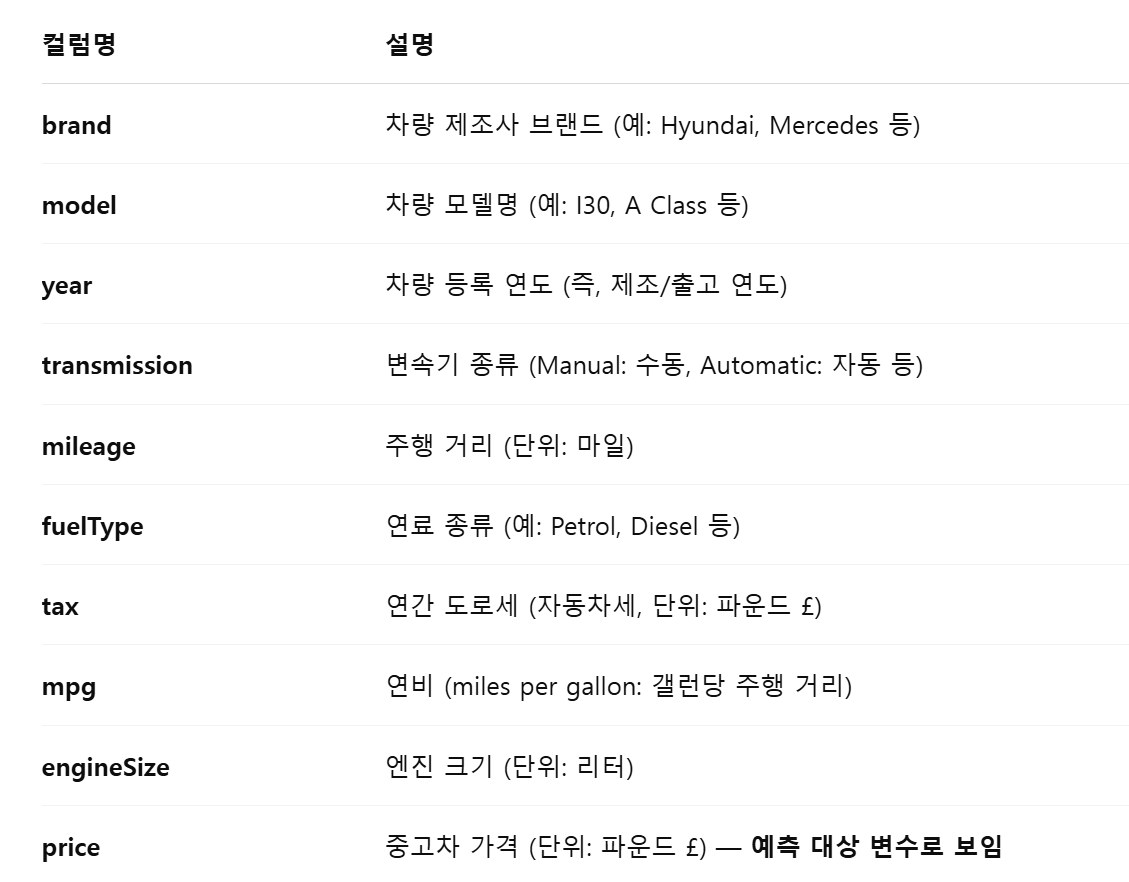

# 필요한 라이브러리들 import

In [3]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib

from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import cross_val_score

from catboost import CatBoostRegressor, Pool

plt.rcParams['font.family'] ='Malgun Gothic'
plt.rcParams['axes.unicode_minus'] =False

In [2]:
# from google.colab import drive
# drive.mount('/content/drive')

# 데이터 불러오기

In [5]:
# data load
# 모델링에 사용할 데이터를 로드해옵니다.
# 본인 로컬 디렉터리로 변경해서 사용
train = pd.read_csv('./dataset/train.csv')
test = pd.read_csv('./dataset/test.csv')

In [6]:
train.head()

,brand,model,year,transmission,mileage,fuelType,tax,mpg,engineSize,price
0,hyundi,I30,2015,Automatic,18078.0,Diesel,20.0,67.3,1.6,8995
1,merc,A Class,2018,Automatic,4350.0,Diesel,145.0,68.9,2.1,19499
2,skoda,Octavia,2019,Manual,9373.0,Diesel,NaN,67.3,1.6,14395
3,toyota,Verso,2011,Manual,74488.0,Petrol,200.0,41.5,1.6,5899
4,merc,C Class,2019,Automatic,608.0,Petrol,145.0,42.2,2.0,26949


필요없는 column(id) 드랍

In [10]:
test.drop(['id'],axis=1, inplace=True)

# 데이터 탐색(EDA)

### 결측치확인

In [14]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58627 entries, 0 to 58626
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   brand         58627 non-null  object 
 1   model         58627 non-null  object 
 2   year          58627 non-null  int64  
 3   transmission  58627 non-null  object 
 4   mileage       57849 non-null  float64
 5   fuelType      58627 non-null  object 
 6   tax           53515 non-null  float64
 7   mpg           53035 non-null  float64
 8   engineSize    58627 non-null  float64
 9   price         58627 non-null  int64  
dtypes: float64(4), int64(2), object(4)
memory usage: 4.5+ MB


In [15]:
# Check for missing values in the 'train' DataFrame.
train.isnull().sum()

brand              0
model              0
year               0
transmission       0
mileage          778
fuelType           0
tax             5112
mpg             5592
engineSize         0
price              0
dtype: int64

mileage, tax, mpg에서 결측치 확인 가능



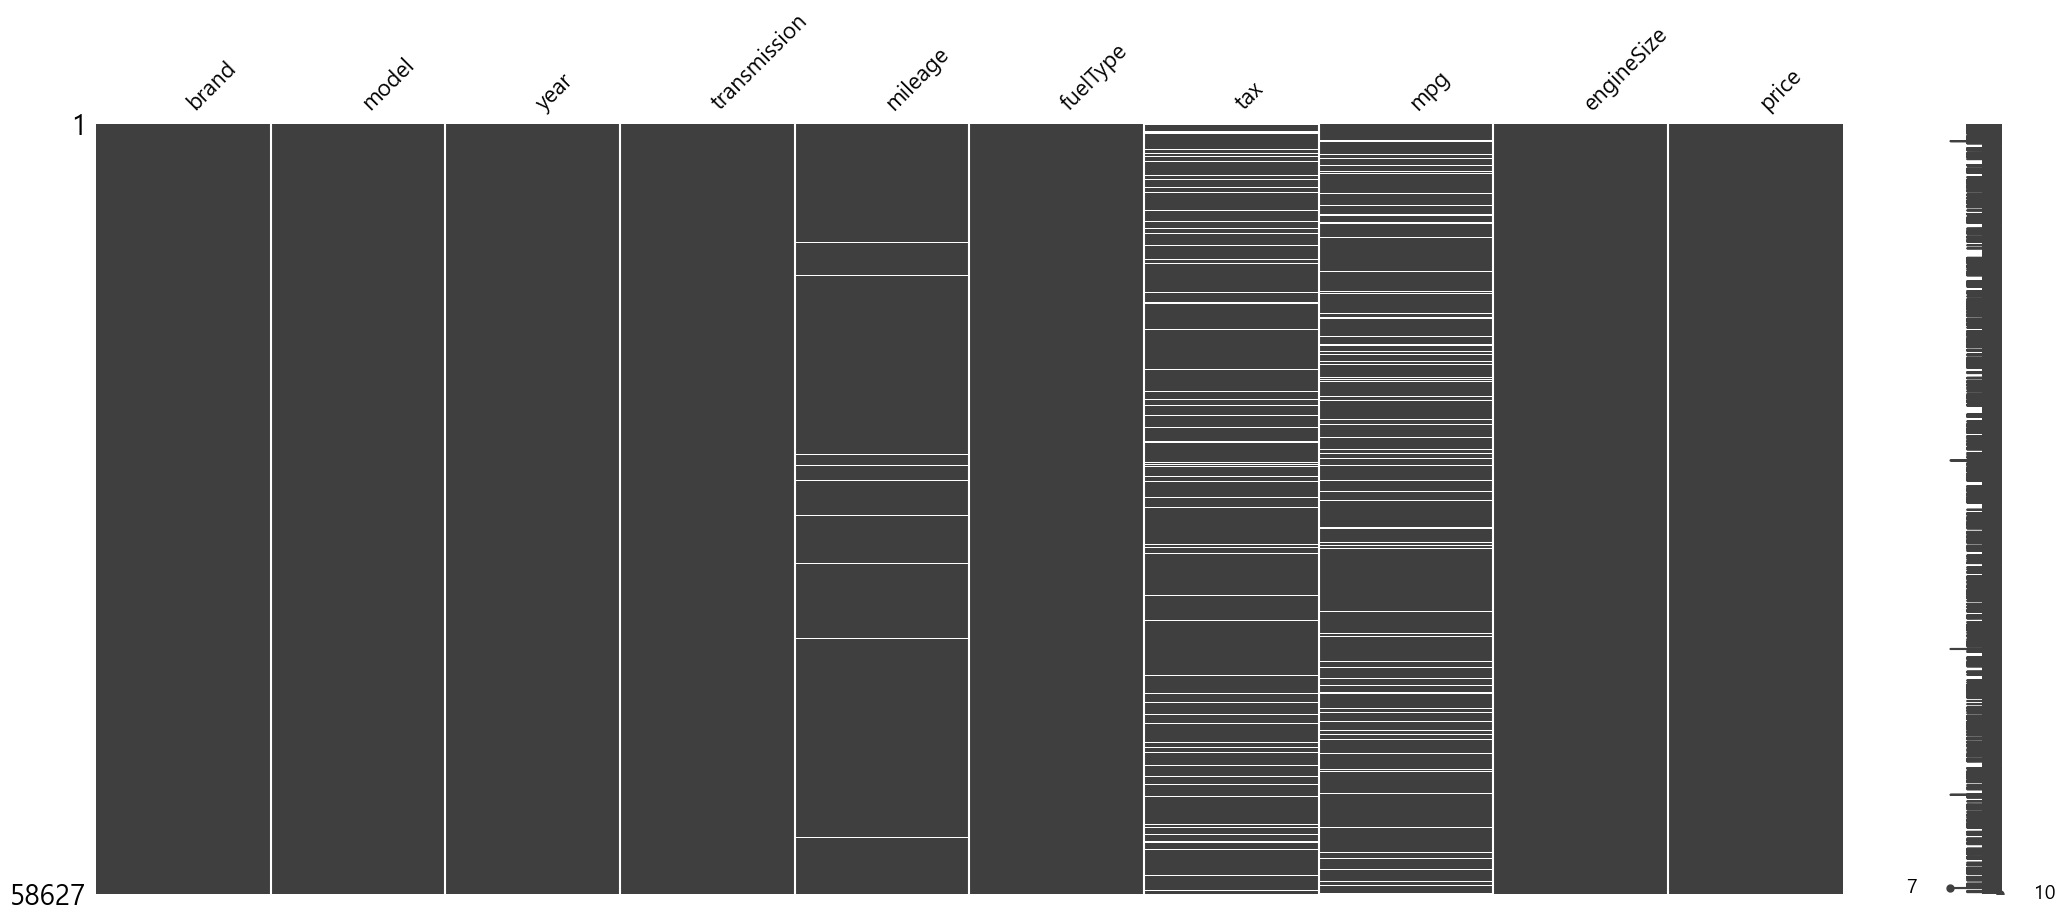

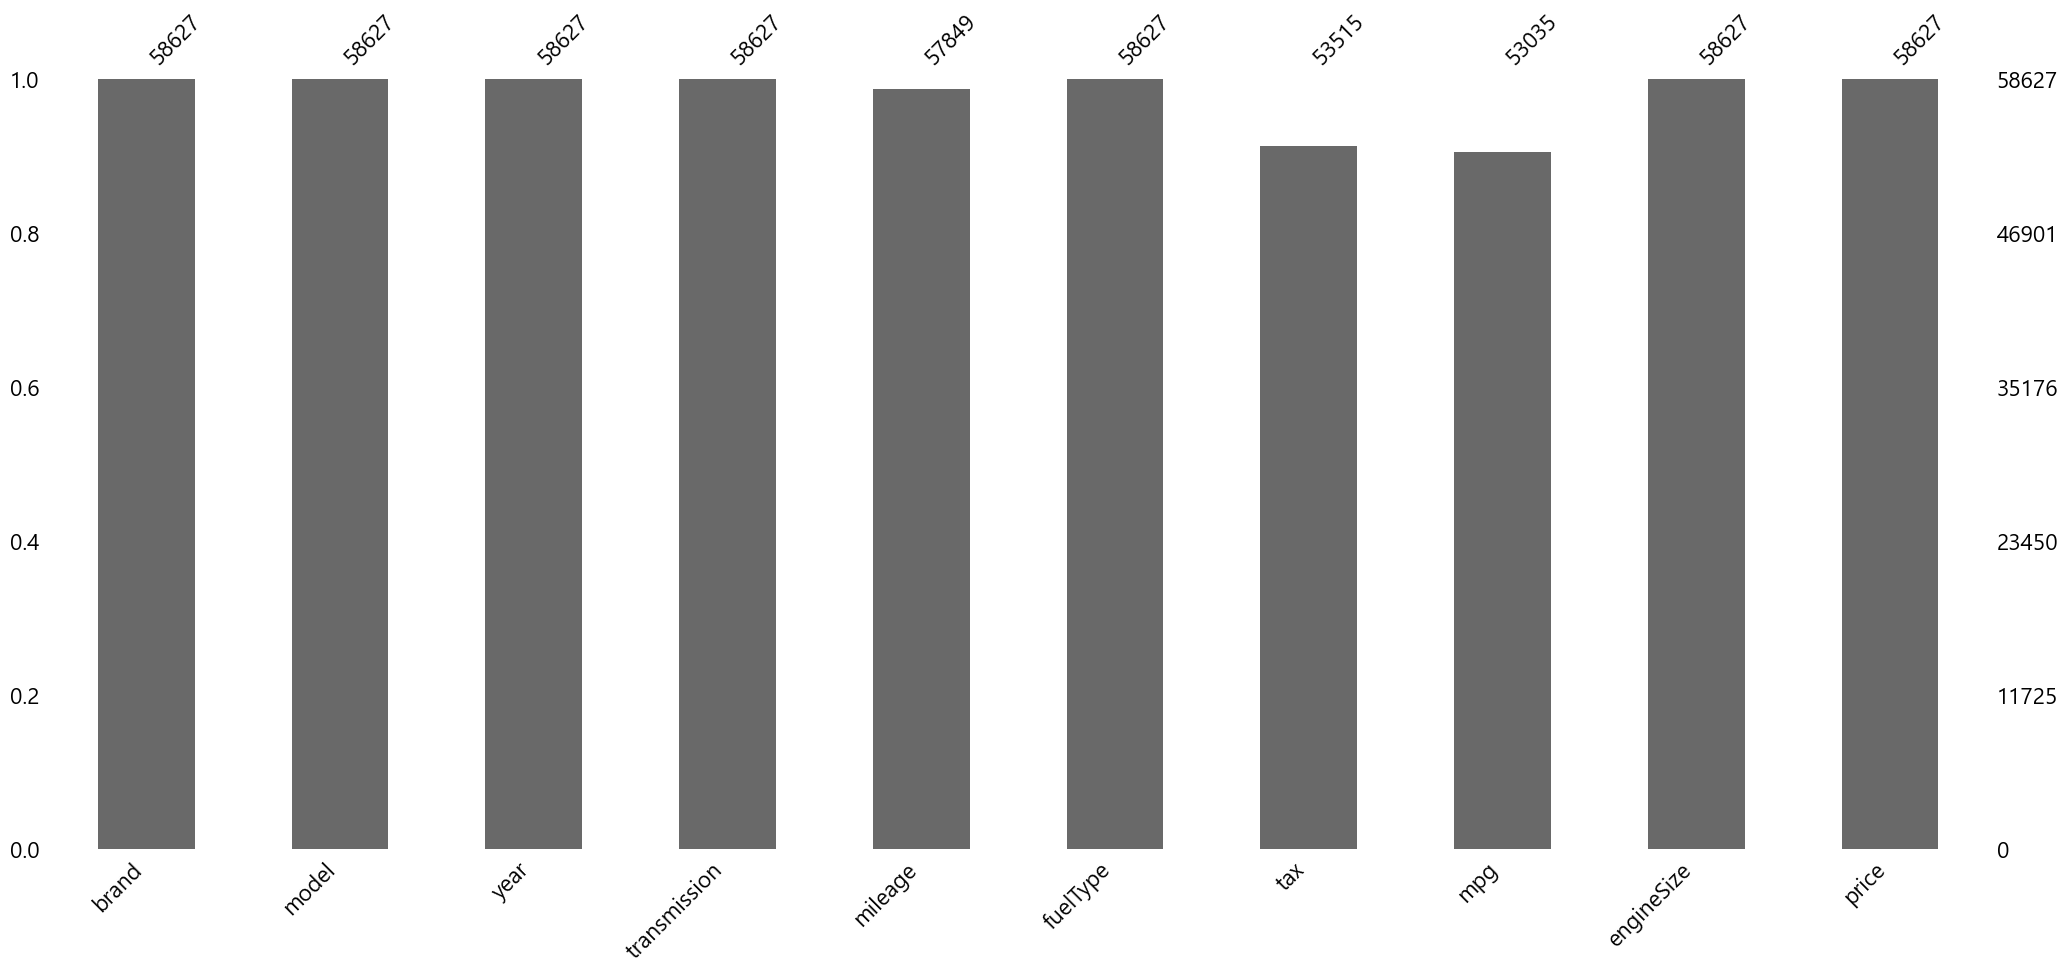

In [17]:
# prompt: train에서의 결측치를 시각적으로 확인하고 싶어

import missingno as msno
import matplotlib.pyplot as plt

# 결측치 시각화
msno.matrix(train)
plt.show()

msno.bar(train)
plt.show()

### 이상치 확인

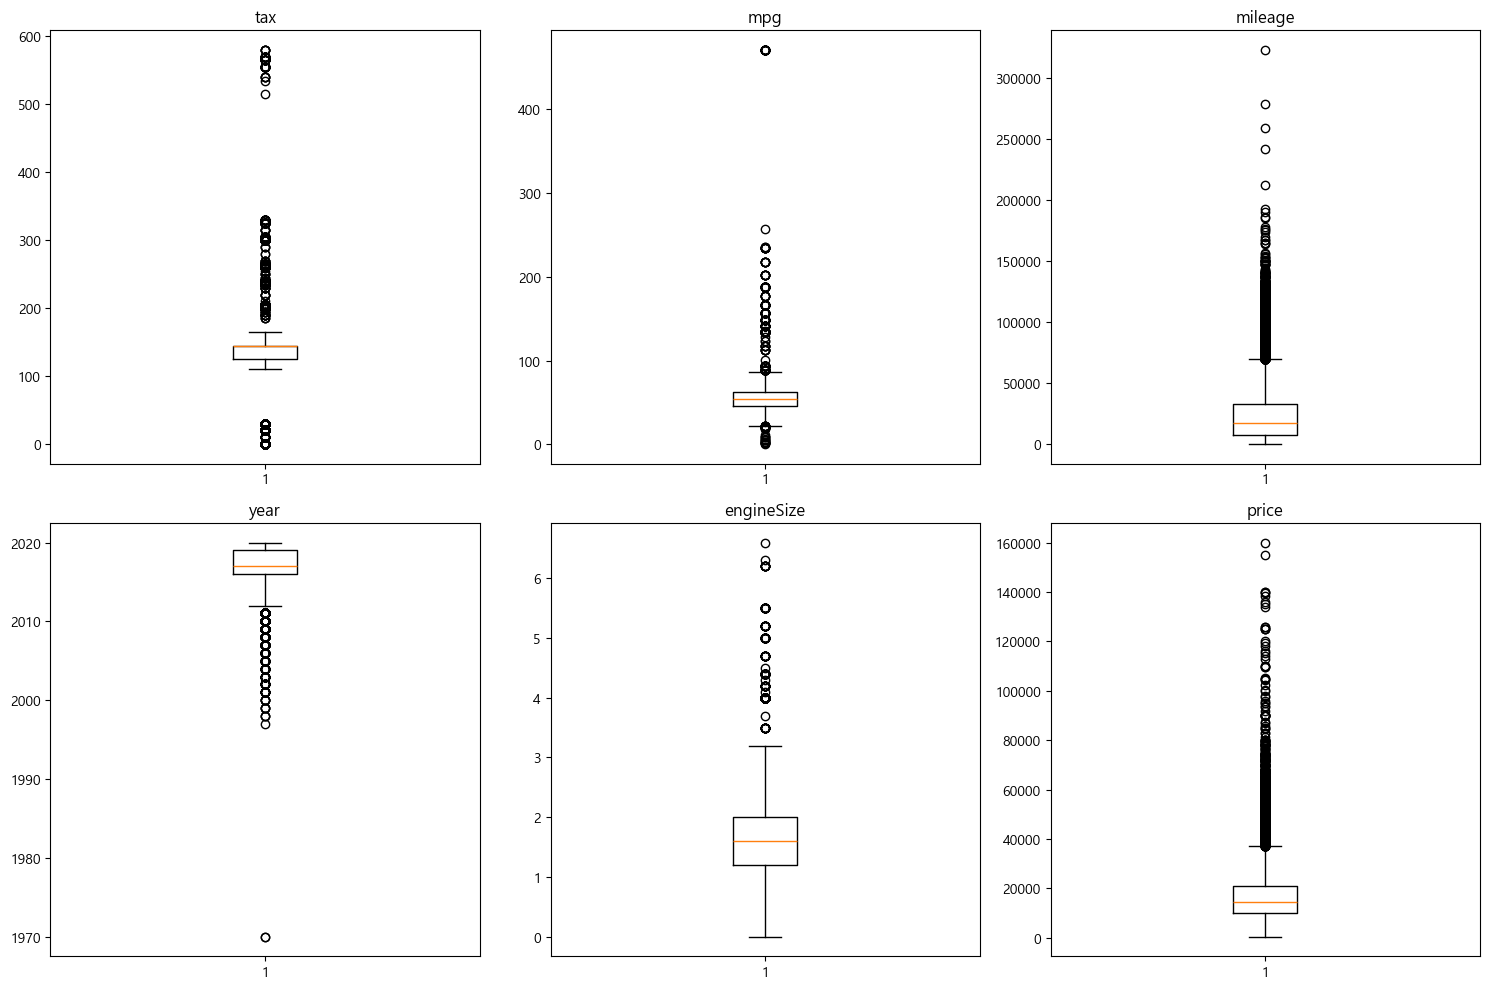

In [20]:
# 숫자형 데이터 열 선택
numerical_cols = ['tax', 'mpg', 'mileage', 'year', 'engineSize', 'price']  # 실제 데이터의 숫자형 열 이름으로 변경

plt.figure(figsize=(15, 10))  # figsize는 원하는 크기로 조정 가능

for i, col in enumerate(numerical_cols):
    plt.subplot(2, 3, i + 1)  # 2행 3열로 subplot 배치
    plt.boxplot(train[col].dropna())  # 결측치 제거 후 박스플롯 생성
    plt.title(col)

plt.tight_layout()
plt.show()

mileage가 크다는건 그만큼 차를 많이 탄다는 말인데, 그렇다면 이 사실이 price에 영향을 주지 않을까?

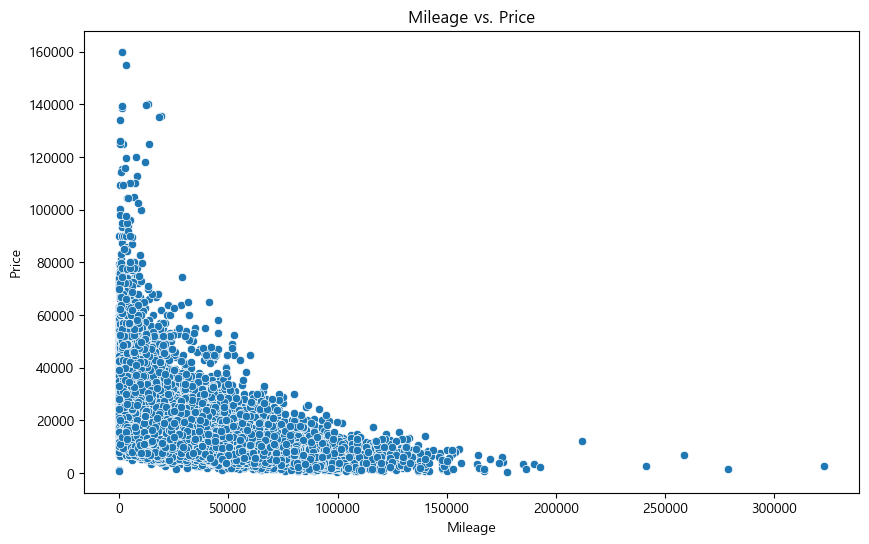

In [22]:
# prompt: train에서 mileage에 따른 가격분포를 확인하고 싶어
import matplotlib.pyplot as plt
import seaborn as sns

# mileage에 따른 가격 분포
plt.figure(figsize=(10, 6))
sns.scatterplot(x='mileage', y='price', data=train)
plt.title('Mileage vs. Price')
plt.xlabel('Mileage')
plt.ylabel('Price')
plt.show()


mileage와 price간 비선형 관계 관측가능 + mileage 감소에 따라 price는 상승하는 경향 어느정도 관측

수치형 변수들 간의 상관성 파악 위해 히트맵 생성

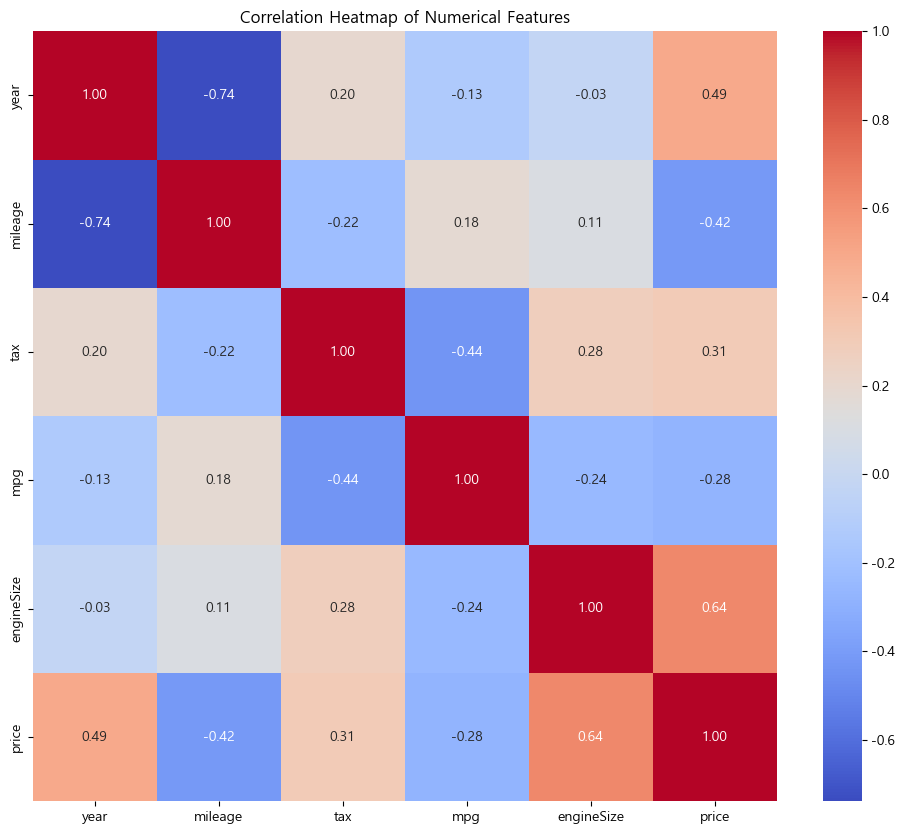

In [26]:
import matplotlib.pyplot as plt
import numpy as np
# 수치형 변수 선택
numerical_cols = train.select_dtypes(include=np.number).columns

# 히트맵 생성
plt.figure(figsize=(12, 10))
sns.heatmap(train[numerical_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Numerical Features')
plt.show()


결측치가 존재하는 column중 tax부터 검토해보자

In [28]:
# Check for missing values in the 'tax' column
missing_tax_data = train[train['tax'].isnull()]

# Print the rows with missing 'tax' values
missing_tax_data


,brand,model,year,transmission,mileage,fuelType,tax,mpg,engineSize,price
2,skoda,Octavia,2019,Manual,9373.0,Diesel,NaN,67.3,1.6,14395
19,vw,Scirocco,2016,Manual,30989.0,Petrol,NaN,46.3,2.0,14750
26,skoda,Fabia,2014,Automatic,70000.0,Petrol,NaN,53.3,1.2,5495
28,merc,CLA Class,2017,Automatic,20182.0,Diesel,NaN,67.3,2.1,16850
35,vauxhall,Astra,2018,Semi-Auto,1414.0,Petrol,NaN,51.4,1.4,12498
...,...,...,...,...,...,...,...,...,...,...
58598,merc,E Class,2016,Automatic,25000.0,Diesel,NaN,65.7,2.0,18990
58600,merc,CLA Class,2015,Automatic,90740.0,Diesel,NaN,67.3,2.1,13795
58607,merc,X-CLASS,2017,Automatic,22500.0,Diesel,NaN,35.8,2.3,29990
58612,bmw,X1,2017,Semi-Auto,11857.0,Diesel,NaN,55.4,2.0,21480


In [29]:
train.head()

,brand,model,year,transmission,mileage,fuelType,tax,mpg,engineSize,price
0,hyundi,I30,2015,Automatic,18078.0,Diesel,20.0,67.3,1.6,8995
1,merc,A Class,2018,Automatic,4350.0,Diesel,145.0,68.9,2.1,19499
2,skoda,Octavia,2019,Manual,9373.0,Diesel,NaN,67.3,1.6,14395
3,toyota,Verso,2011,Manual,74488.0,Petrol,200.0,41.5,1.6,5899
4,merc,C Class,2019,Automatic,608.0,Petrol,145.0,42.2,2.0,26949


In [30]:
import pandas as pd
import numpy as np

# 숫자형 데이터만 선택 (문자열 데이터가 포함된 컬럼은 제외)
train_numeric = train.select_dtypes(include=[np.number])

# 상관관계 행렬 계산
correlation_matrix = train_numeric.corr()

# 'tax'와의 상관관계 절대값 계산 후 내림차순 정렬
tax_correlations = abs(correlation_matrix['tax']).sort_values(ascending=False)

# 상관관계 결과 출력
print(tax_correlations)

# 'tax'를 제외한 가장 높은 상관관계를 가진 변수 선택
most_influential_variable = tax_correlations.index[1]  # 인덱스 0은 'tax' 자체
print(f"\n'tax'에 가장 큰 영향을 주는 변수는: {most_influential_variable}")


tax           1.000000
mpg           0.439685
price         0.306311
engineSize    0.279493
mileage       0.218237
year          0.197673
Name: tax, dtype: float64

'tax'에 가장 큰 영향을 주는 변수는: mpg


In [31]:
# prompt: 같은 차량이면 같은 tax값인지를 확인해보고 싶어

# Check if the same car has the same tax value
same_car_same_tax = train.groupby('model')['tax'].nunique()
print(same_car_same_tax)

# Count the number of cars with different tax values
different_tax_cars = same_car_same_tax[same_car_same_tax > 1]
print(f"\nNumber of car models with different tax values: {len(different_tax_cars)}")

# Display the car models with different tax values
print("\nCar models with different tax values:")
different_tax_cars

# You can further investigate these cars:
# for car_name in different_tax_cars.index:
#    print(f"\nDetails for car model: {car_name}")
#    print(train[train['car_name'] == car_name])


model
1 Series         17
2 Series         15
3 Series         24
4 Series         12
5 Series         17
                 ..
Z4                8
Zafira           12
Zafira Tourer     7
i3                3
i8                3
Name: tax, Length: 186, dtype: int64

Number of car models with different tax values: 169

Car models with different tax values:


model
1 Series         17
2 Series         15
3 Series         24
4 Series         12
5 Series         17
                 ..
Z4                8
Zafira           12
Zafira Tourer     7
i3                3
i8                3
Name: tax, Length: 169, dtype: int64

차종이 같다고 tax가 꼭 같지는 않구나!

In [33]:
train['tax'].unique()

array([ 20., 145.,  nan, 200.,  30.,   0., 150., 135., 235., 125., 260.,
       160., 300., 205., 165., 140., 325., 330., 240., 265., 115., 555.,
       305., 190., 270., 570., 210., 580.,  10., 110., 540., 230., 565.,
       515., 250., 280., 220., 155., 245., 120., 290., 185., 315., 195.,
       535., 255.])

In [34]:
print(len(train['tax'].unique()))

46


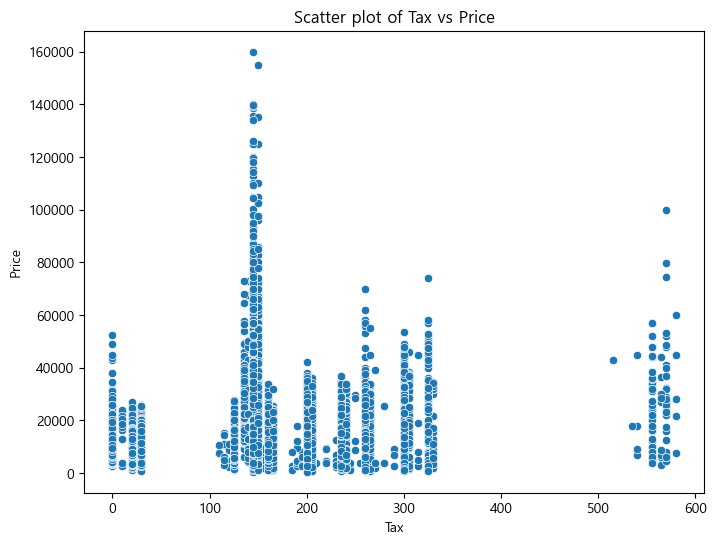

In [35]:
# tax 컬럼과 다른 변수 간의 관계 확인 (scatter plot)
# 예시: tax와 price의 관계
plt.figure(figsize=(8, 6))
sns.scatterplot(x=train['tax'], y=train['price'])
plt.title('Scatter plot of Tax vs Price')
plt.xlabel('Tax')
plt.ylabel('Price')
plt.show()

### EDA - transmission

In [38]:
train['transmission'].unique()

array(['Automatic', 'Manual', 'Semi-Auto', 'Other'], dtype=object)

샤피로 윌크 검정으로 각 group이 정규성 가지는지 검정한다!

In [40]:
import pandas as pd
from scipy.stats import shapiro

data = train
transmissions = data['transmission'].unique()

for transmission in transmissions:
    subset = data[data['transmission'] == transmission]['price'].dropna()
    stat, p_value = shapiro(subset)
    print(f"{transmission}: p-value = {p_value:.4f}")
#아무 group도 정규성 가지지 않음. Other도 데이터 포인트가 6개인걸 고려하면 통계적으로 의미X

Automatic: p-value = 0.0000
Manual: p-value = 0.0000
Semi-Auto: p-value = 0.0000
Other: p-value = 0.5700


C:\Users\thdck\Dropbox\송찬호\수업\데이터마이닝\팀프로젝트\myenv\Lib\site-packages\scipy\stats\_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 12018.
  res = hypotest_fun_out(*samples, **kwds)
C:\Users\thdck\Dropbox\송찬호\수업\데이터마이닝\팀프로젝트\myenv\Lib\site-packages\scipy\stats\_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 33205.
  res = hypotest_fun_out(*samples, **kwds)
C:\Users\thdck\Dropbox\송찬호\수업\데이터마이닝\팀프로젝트\myenv\Lib\site-packages\scipy\stats\_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 13398.
  res = hypotest_fun_out(*samples, **kwds)


In [41]:
train['transmission'].value_counts()

transmission
Manual       33205
Semi-Auto    13398
Automatic    12018
Other            6
Name: count, dtype: int64

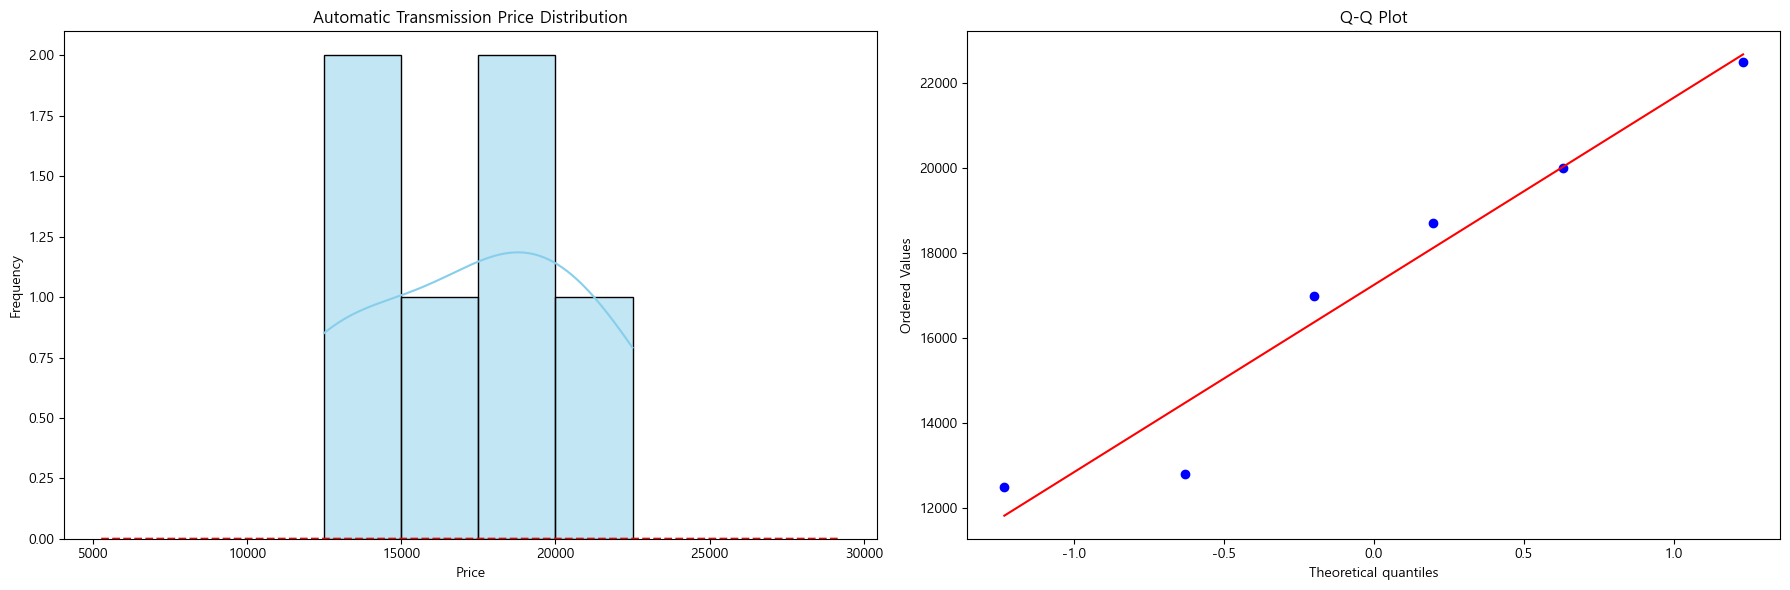

In [42]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# 데이터 로드
data = train

# Automatic 그룹 필터링
auto_prices = data[data['transmission'] == 'Other']['price'].dropna()

# 그래프 설정
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# 히스토그램 + KDE
sns.histplot(auto_prices, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Automatic Transmission Price Distribution')
axes[0].set_xlabel('Price')
axes[0].set_ylabel('Frequency')

# 정규 분포 곡선 추가
mu, sigma = auto_prices.mean(), auto_prices.std()
x = np.linspace(mu - 3*sigma, mu + 3*sigma, 100)
axes[0].plot(x, stats.norm.pdf(x, mu, sigma), color='red', linestyle='--')

# Q-Q 플롯
stats.probplot(auto_prices, plot=axes[1])
axes[1].set_title('Q-Q Plot')

plt.tight_layout()
plt.show()


정규성 가정을 만족하지 않음. 따라서 anova 사용 불가.

Kruskal-Wallis H-statistic: 21277.534909356313
p-value: 0.0


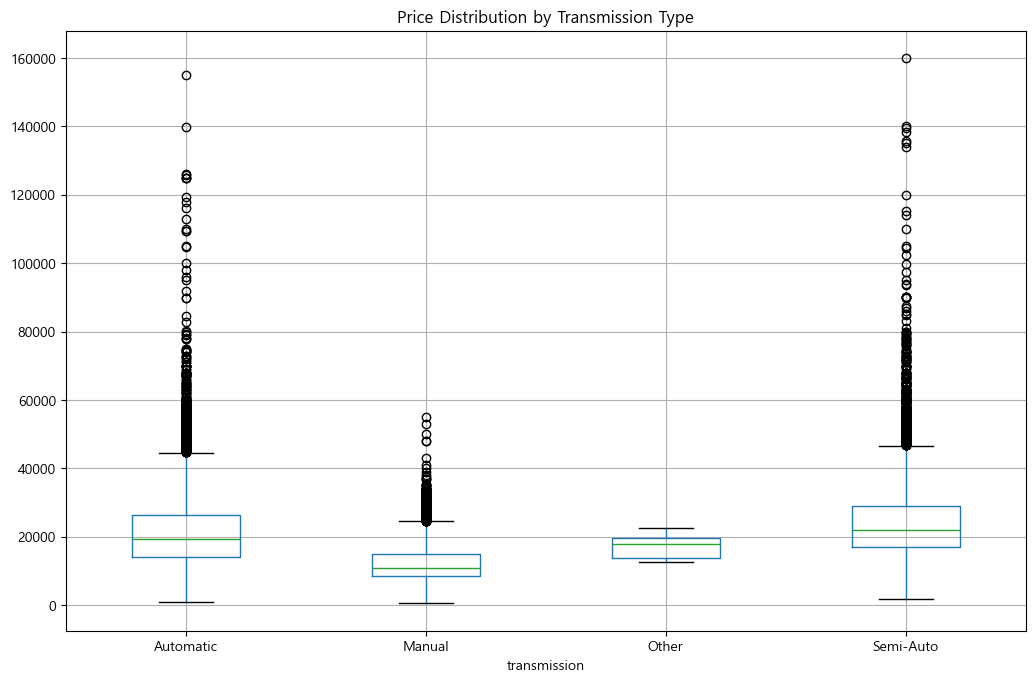

In [45]:
import pandas as pd
from scipy.stats import kruskal

# transmission별 price 데이터 그룹화
groups = []
for transmission in data['transmission'].unique():
    group = data[data['transmission'] == transmission]['price'].dropna()
    groups.append(group)

# Kruskal-Wallis 검정 수행
h_stat, p_value = kruskal(*groups)

# 결과 출력
print("Kruskal-Wallis H-statistic:", h_stat)
print("p-value:", p_value)

# 박스플롯 시각화
import matplotlib.pyplot as plt
data.boxplot(column='price', by='transmission', figsize=(12,8))
plt.title('Price Distribution by Transmission Type')
plt.suptitle('')
plt.show()


In [46]:
!pip install scikit-posthocs

위의 검정으로는 차이가 있는 group이 "있다"만 파악 가능 => 적어도 한 group이 다르다! 는 말임.
 따라서 "어떤" group끼리 유의미한 중앙값 차이(비모수 검정이므로 중앙값 이용)가 있는지 알기 위해 pair로 사후검정 실시한다.

In [49]:
import scikit_posthocs as sp

# Dunn’s test (Bonferroni 보정 포함)
dunn_result = sp.posthoc_dunn(data, val_col='price', group_col='transmission', p_adjust='bonferroni')

# 결과 출력
print("Dunn's post-hoc test with Bonferroni correction:")
print(dunn_result)


ModuleNotFoundError: No module named 'scikit_posthocs'

정확한 transmission 알 수 없는 Other 외에 나머지 group끼리는 p-value < 0.05를 만족하여 귀무가설 "두 그룹 간 중앙값(또는 분포)에 차이가 없다" 를 기각하게 됨.
따라서 Automatic, Manual, Semi-Auto group사이에 price 분포 차이가 통계적으로 유의미하다!

In [55]:
# 그룹별 price 중앙값을 계산하고 오름차순 정렬
median_prices_sorted = data.groupby('transmission')['price'].median().sort_values(ascending = False)
print(median_prices_sorted)

transmission
Semi-Auto    22045.5
Automatic    19246.5
Other        17847.5
Manual       11000.0
Name: price, dtype: float64


의외로 Semi - Auto가 더 중앙값이 높네

### EDA - tax

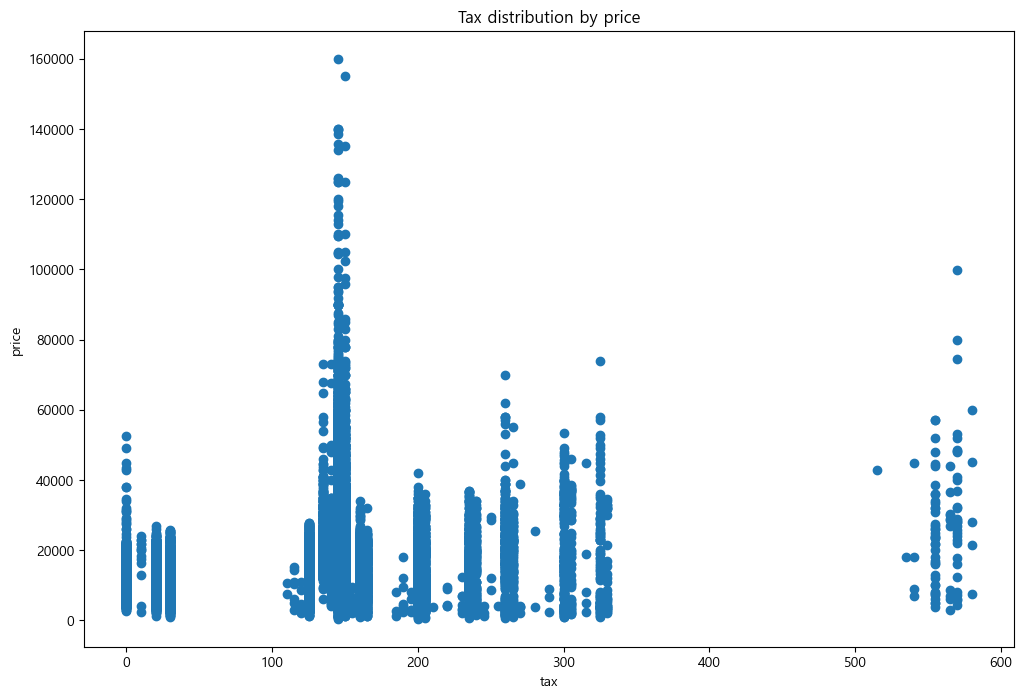

In [59]:
plt.figure(figsize=(12,8))
plt.scatter(y=train['price'], x=train['tax'])
plt.title("Tax distribution by price")
plt.xlabel('tax')
plt.ylabel('price')
plt.show()

- 위의 그래프에서 tax가 0 근처에 있는 걸 이상치 처리해야 하나? => 영국에는 road tax가 존재. 특정 조건을 만족한다면 도로세를 내지 않아도 됨.
- 500파운드가 넘는 tax도 실제 중고차 세금 범위 내에 존재함

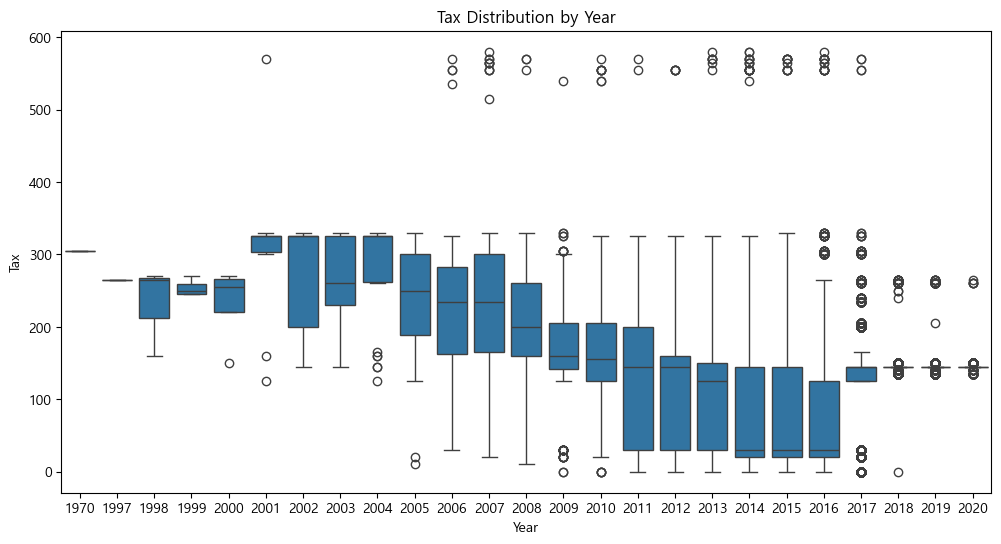

In [61]:
# tax 분포 비교를 위한 boxplot
plt.figure(figsize=(12, 6))
sns.boxplot(x='year', y='tax', data=train) #hue='fuelType' 추가 가능
plt.title('Tax Distribution by Year')
plt.xlabel('Year')
plt.ylabel('Tax')
plt.show()

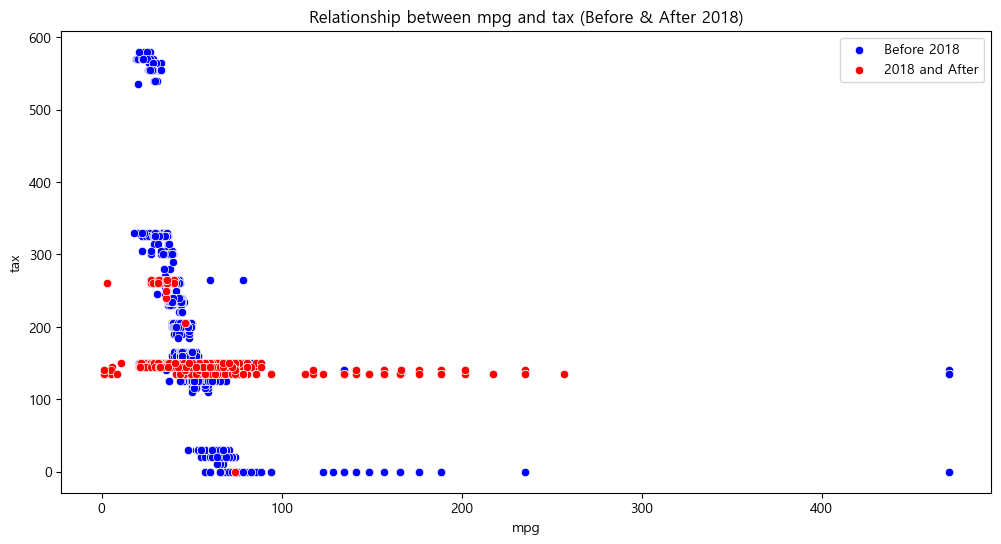

In [63]:
plt.figure(figsize=(12, 6))

# 2018년 이전 데이터
sns.scatterplot(data=train[train['year'] < 2018], x='mpg', y='tax', color='blue', label='Before 2018')

# 2018년 이후 데이터
sns.scatterplot(data=train[train['year'] >= 2018], x='mpg', y='tax', color='red', label='2018 and After')

plt.title('Relationship between mpg and tax (Before & After 2018)')
plt.xlabel('mpg')
plt.ylabel('tax')
plt.legend()
plt.show()

영국 자동차세(tax)의 변화
- 2017년 4월 이전
 - 자동차세를 차량의 CO2 배출량 기준으로 구간별 차등 과세
 - 친환경 차량은 거의 세금을 안냈고, 고배출 차량은 고세금

- 2017년 4월 이후
 - 대부분 차량이 연료 타입과 관계없이 동일하거나 비슷한 고정 세금

관련링크:https://www.smithsmotorgroup.co.uk/news/2017-road-tax-changes-explained/?srsltid=AfmBOooQjD7-e7mu2Gn8Fnjtykj9-ldt6xZeop6dh_XrcbcyOo6qVng5

- 이를 통해서 해당 데이터가 영국의 데이터라는 것을 알 수 있음

### EDA - Year

year에 대해 이상치 확인,,,,1970년도가 나오는게 말이 되나?

In [70]:
train[train['year'] == 1970]

,brand,model,year,transmission,mileage,fuelType,tax,mpg,engineSize,price
18945,vauxhall,Zafira,1970,Manual,37357.0,Petrol,NaN,42.2,1.4,10495
54861,merc,M Class,1970,Automatic,14000.0,Diesel,305.0,39.2,0.0,24999


In [72]:
train_eda = train.copy()

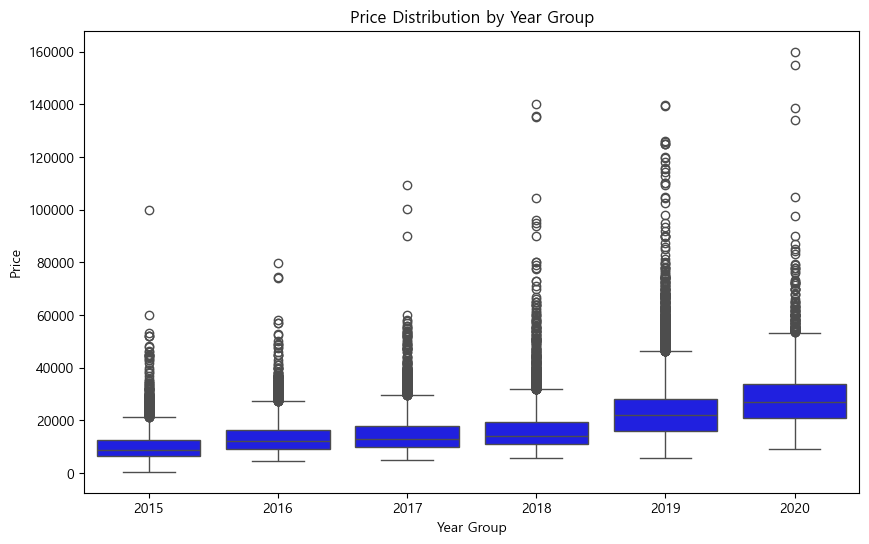

In [74]:
# 등록 연도가 최신일수록 가격이 높을까?

#연도를 범주형 그룹으로 변환
bins = [1960, 2015, 2016, 2017, 2018, 2019, 2020]
labels = ['2015', '2016', '2017', '2018', '2019', '2020']
train_eda['year_group'] = pd.cut(train_eda['year'], bins=bins, labels=labels, right=True)

# 박스플롯으로 시각화
plt.figure(figsize=(10, 6))
sns.boxplot(y='price', x='year_group', data=train_eda, color='blue')
plt.title('Price Distribution by Year Group')
plt.xlabel('Year Group')
plt.ylabel('Price')
plt.show()

- 등록 연도가 최근일수록 가격의 중앙값과 분포의 상한선이 함께 올라감

### EDA - enginesize

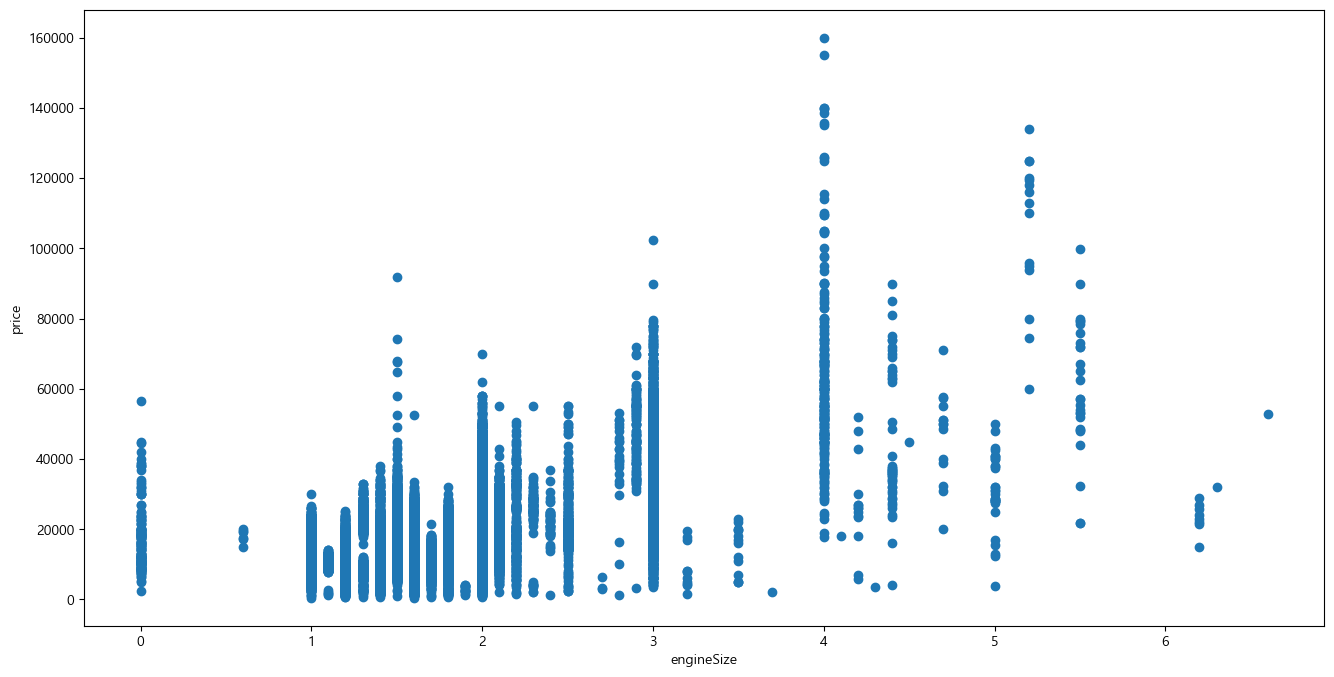

In [78]:
# enginesize와 price의 관계

plt.figure(figsize=(16,8))

plt.scatter(y=train['price'], x=train['engineSize'])
plt.xlabel('engineSize')
plt.ylabel('price')
plt.show()

- 전기차는 배기량이 0일 수 있지만, 내연기관이 탑재된 차량은 배기량이 0이 될 수 없음.

In [87]:
train['engineSize'].value_counts()

engineSize
2.0    16146
1.0    10193
1.5     6768
1.4     6548
1.6     5257
1.2     4037
3.0     3211
2.1     2381
1.8     1047
1.3      765
1.7      525
1.1      334
2.5      307
2.2      267
4.0      209
0.0      162
2.9      106
2.3       85
4.4       49
2.4       42
5.0       31
5.5       27
2.8       24
5.2       15
1.9       15
4.7       14
3.5       14
4.2       14
3.2       11
6.2        8
0.6        6
2.7        3
6.6        1
6.3        1
3.7        1
4.3        1
4.1        1
4.5        1
Name: count, dtype: int64

# 데이터 전처리(Data Preprocessing)


## 데이터 가공 전 학습과 테스트용 데이터 세트 결합
- 데이터 가공 시 train과 test데이터에 동일한 가공을 진행하기 위해 결합을 진행함

In [89]:
df=pd.concat([train, test])
print(df.shape)

(97712, 10)


In [91]:
# 중복되는 index 값이 생겨 index 값 재설정

df.reset_index(drop=True, inplace=True)

In [93]:
df.shape

(97712, 10)

## 결측치 대체
- 각 컬럼의 평균값으로 결측치 대체

### mpg 결측치 대체
- 동일한 기종이라면 동일한 mpg를 가질 것으로 판단

In [97]:
# import pandas as pd
# mpg 결측치 처리
# def fill_missing_mpg(df):
#     for index in df.index:
#         if pd.isnull(df.loc[index, 'mpg']):
#             brand = df.loc[index, 'brand']
#             model = df.loc[index, 'model']
#             transmission = df.loc[index, 'transmission']
#             year = df.loc[index, 'year']
#             fuelType = df.loc[index, 'fuelType']

#             mean_mpg = df[(df['brand'] == brand) & (df['model'] == model) &
#                           (df['transmission'] == transmission) & (df['year'] == year) &
#                           (df['fuelType'] == fuelType)]['mpg'].mean()

#             if pd.notnull(mean_mpg):
#                 df.loc[index, 'mpg'] = mean_mpg
#     return df

# df = fill_missing_mpg(df)

In [98]:
# 완전히 동일한 모델이 존재하지 않는 경우에는 brand, model, year이 같은 경우로 한함
# def fill_missing_mpg(df):
#     for index in df.index:
#         if pd.isnull(df.loc[index, 'mpg']):
#             brand = df.loc[index, 'brand']
#             model = df.loc[index, 'model']
#             year = df.loc[index, 'year']

#             mean_mpg = df[(df['brand'] == brand) & (df['model'] == model) & (df['year'] == year)]['mpg'].mean()

#             if pd.notnull(mean_mpg):
#                 df.loc[index, 'mpg'] = mean_mpg
#             else:
#                 # Handle cases where no matching brand, model, and year are found
#                 # For example, fill with the overall mean mpg or a specific value
#                 df.loc[index, 'mpg'] = df['mpg'].mean() # Or another strategy
#     return df
# df = fill_missing_mpg(df)

In [99]:
# df.to_pickle('mpg.pkl')

In [100]:
df = pd.read_pickle('mpg.pkl')

In [101]:
df.shape

(97712, 10)

In [111]:
print(df.isnull().sum())

brand               0
model               0
year                0
transmission        0
mileage           778
fuelType            0
tax              5112
mpg                 0
engineSize          0
price           39085
dtype: int64


### tax결측치 대체
- tax의 결측치는 최빈값으로 대체

In [117]:
# tax 최빈값으로 대체
df['tax'] = df['tax'].fillna(df['tax'].mode()[0])

In [119]:
print(df.isnull().sum())

brand               0
model               0
year                0
transmission        0
mileage           778
fuelType            0
tax                 0
mpg                 0
engineSize          0
price           39085
dtype: int64


### mileage 결측치 삭제
- mileage(주행거리)는 year연식에 따라 영향을 받을 것으로 판단

In [122]:

# mileage 결측치를 평균값으로 채웁니다.
df['mileage'] = df['mileage'].fillna(df['mileage'].mean())
print(df.isnull().sum())


brand               0
model               0
year                0
transmission        0
mileage             0
fuelType            0
tax                 0
mpg                 0
engineSize          0
price           39085
dtype: int64


In [124]:
print(df.isnull().sum())

brand               0
model               0
year                0
transmission        0
mileage             0
fuelType            0
tax                 0
mpg                 0
engineSize          0
price           39085
dtype: int64


## 이상치 처리
- year가 1970인 데이터 삭제
- year가 현재 년도보다 높은 데이터 수정필요
- engineSize가 0인 데이터 처리 필요

### year 이상치 처리
- 1970년대에 해당 모델들의 자동차가 생산되지 않았음
- 2건의 데이터이기 때문에 삭제 진행

In [128]:
cond_1970 = df['year'] == 1970
cond_2060 = df['year'] == 2060

df[cond_1970 | cond_2060][['brand', 'model','year','price']]

,brand,model,year,price
18945,vauxhall,Zafira,1970,10495.0
54861,merc,M Class,1970,24999.0
78186,ford,Fiesta,2060,NaN


In [130]:
# Assuming 'df' is your combined dataframe as defined in the provided code.
df = df[df['year'] != 1970]

In [132]:
df[df['year'] == 1970]

,brand,model,year,transmission,mileage,fuelType,tax,mpg,engineSize,price


- test데이터 셋에 연식 2060인 데이터 확인
- 해당 데이터의 연식 변경 -> 2023년을 기점으로 단종

In [135]:
# Assuming 'df' is your combined dataframe as defined in the provided code.
df.loc[df['year'] == 2060, 'year'] = 2020

In [137]:
df[df['year'] == 2060]

,brand,model,year,transmission,mileage,fuelType,tax,mpg,engineSize,price


## VIF 측정
- 독립변수 간의 다중공선성 문제가 발생했는지를 확인

In [140]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# VIF 계산을 위한 데이터프레임 생성
X = df[['year','engineSize','mileage','tax','mpg']]
# X.drop('price',axis=1, inplace =True)

# # VIF 계산
vif = pd.DataFrame()
vif["VIF Factor"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif["features"] = X.columns

vif

ModuleNotFoundError: No module named 'statsmodels'

## 파생변수 생성
- 차량의 사용 강도를 확인할 수 있는 mile_per_year 파생변수 생성
- 다중공선성을 완화하는 방법 중 하나

In [ ]:
mileage_per_year = df['mileage'] / (2025 - df['year'])
df['mileage_per_year'] =mileage_per_year

In [ ]:
numerical_cols =['tax', 'mileage_per_year', 'mpg', 'engineSize',]


# VIF 계산을 위한 데이터프레임 생성
X = df[numerical_cols]
# X.drop('price',axis=1, inplace =True)

# # VIF 계산
vif = pd.DataFrame()
vif["VIF Factor"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif["features"] = X.columns

vif

### 인코딩


### 원핫인코딩

In [ ]:
# 범주형 컬럼 지정
# categorical_cols = ['brand', 'model', 'transmission', 'fuelType']

# # 원핫인코딩 수행
# df = pd.get_dummies(df, columns=categorical_cols)

In [ ]:
# df.shape

### 라벨 인코딩

In [143]:
#범주형 변수 라벨 인코딩
from sklearn.preprocessing import LabelEncoder

# 범주형 컬럼 지정 (이전 코드에서 원핫 인코딩으로 처리한 변수 제외)
categorical_cols = ['brand', 'model', 'transmission', 'fuelType'] # brand, model은 원핫인코딩으로 처리했으므로 제외

# LabelEncoder 객체 생성
label_encoder = LabelEncoder()

# 각 범주형 변수에 대해 라벨 인코딩 적용
for col in categorical_cols:
    df[col] = label_encoder.fit_transform(df[col])


C:\Users\thdck\AppData\Local\Temp\ipykernel_20436\488534043.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col] = label_encoder.fit_transform(df[col])
C:\Users\thdck\AppData\Local\Temp\ipykernel_20436\488534043.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col] = label_encoder.fit_transform(df[col])
C:\Users\thdck\AppData\Local\Temp\ipykernel_20436\488534043.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_in

### engineSize 0 이상치 대체
- 물리적으로 내연기관의 엔진사이즈가 0이 될 수는 없음

In [146]:
engine_0 = train[
    (train['engineSize'] == 0) &
    (train['fuelType']   != 'Electric')
]
engine_0.head()

,brand,model,year,transmission,mileage,fuelType,tax,mpg,engineSize,price
525,hyundi,IX35,2015,Manual,26564.0,Petrol,200.0,41.5,0.0,9700
531,audi,Q2,2019,Manual,1076.0,Petrol,145.0,NaN,0.0,23888
696,audi,A3,2005,Manual,122000.0,Diesel,150.0,53.3,0.0,2495
865,audi,Q3,2020,Automatic,1500.0,Petrol,145.0,30.7,0.0,38888
983,merc,A Class,2016,Automatic,29712.0,Diesel,20.0,68.9,0.0,17500


In [99]:
# 값별 개수 (결측치 포함)
counts = train['engineSize'].value_counts()
print(counts)

engineSize
2.0    16146
1.0    10193
1.5     6768
1.4     6548
1.6     5257
1.2     4037
3.0     3211
2.1     2381
1.8     1047
1.3      765
1.7      525
1.1      334
2.5      307
2.2      267
4.0      209
0.0      162
2.9      106
2.3       85
4.4       49
2.4       42
5.0       31
5.5       27
2.8       24
5.2       15
1.9       15
4.7       14
3.5       14
4.2       14
3.2       11
6.2        8
0.6        6
2.7        3
6.6        1
6.3        1
3.7        1
4.3        1
4.1        1
4.5        1
Name: count, dtype: int64


consistent_nunique: 60.7%
consistent_range: 79.7%
consistent_cv: 39.4%


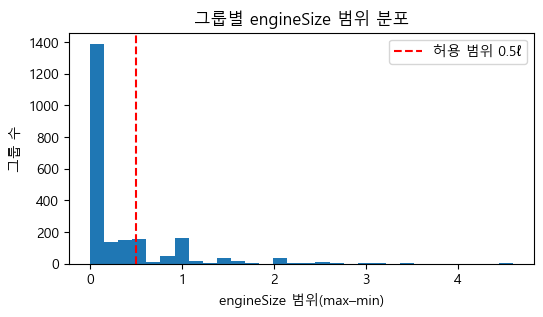

In [83]:
import pandas as pd
import matplotlib.pyplot as plt

# 1) 그룹 통계 계산
stats = (
    train
    .groupby(['brand','model','year','fuelType'])['engineSize']
    .agg([
        ('n_unique', 'nunique'),
        ('min',      'min'),
        ('max',      'max'),
        ('mean',     'mean'),
        ('std',      'std')
    ])
    .reset_index()
)

# 2) 주요 지표 추가
stats['range'] = stats['max'] - stats['min']                    # max–min
stats['cv']    = stats['std'] / stats['mean']                   # 변동계수
stats['consistent_nunique'] = stats['n_unique'] == 1            # 유니크 1개 여부
stats['consistent_range']   = stats['range'] <= 0.5             # 범위 ≤0.5ℓ 여부
stats['consistent_cv']      = stats['cv'] <= 0.05               # CV ≤5% 여부 (예시)

# 3) 전체 그룹 대비 비율 보기
total_groups = len(stats)
for col in ['consistent_nunique','consistent_range','consistent_cv']:
    pct = stats[col].mean() * 100
    print(f"{col}: {pct:.1f}%")

# 4) 분포 시각화 (max–min 히스토그램 예시)
plt.figure(figsize=(6,3))
plt.hist(stats['range'].dropna(), bins=30)
plt.axvline(0.5, color='red', linestyle='--', label='허용 범위 0.5ℓ')
plt.xlabel('engineSize 범위(max–min)')
plt.ylabel('그룹 수')
plt.title('그룹별 engineSize 범위 분포')
plt.legend()
plt.show()


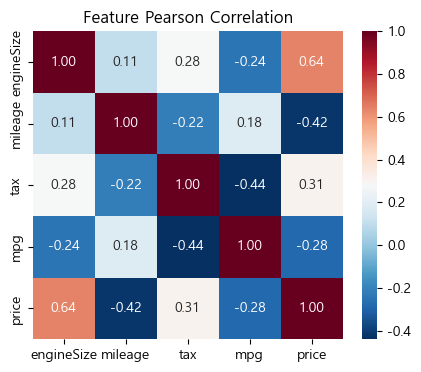

       level_0     level_1         0
1   engineSize     mileage  0.105546
2   engineSize         tax  0.279493
3   engineSize         mpg  0.244332
4   engineSize       price  0.639335
5      mileage  engineSize  0.105546
7      mileage         tax  0.218237
8      mileage         mpg  0.180769
9      mileage       price  0.418112
10         tax  engineSize  0.279493
11         tax     mileage  0.218237
13         tax         mpg  0.439685
14         tax       price  0.306311
15         mpg  engineSize  0.244332
16         mpg     mileage  0.180769
17         mpg         tax  0.439685
19         mpg       price  0.283272
20       price  engineSize  0.639335
21       price     mileage  0.418112
22       price         tax  0.306311
23       price         mpg  0.283272


In [85]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1) 상관계수 매트릭스
corr = train[['engineSize','mileage','tax','mpg','price']].corr()

# 2) 히트맵 시각화
plt.figure(figsize=(5,4))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r")
plt.title("Feature Pearson Correlation")
plt.show()

# 3) 강한 관계만 필터링
strong_linear = (
    corr.stack()
        .abs()
        .reset_index()
        .query("level_0 != level_1 and 0.7 <= 0.7")  # 예: 0.7 기준
)
print(strong_linear)


Mutual Information:
 mpg        0.538645
price      0.383437
tax        0.189988
mileage    0.077026
dtype: float64


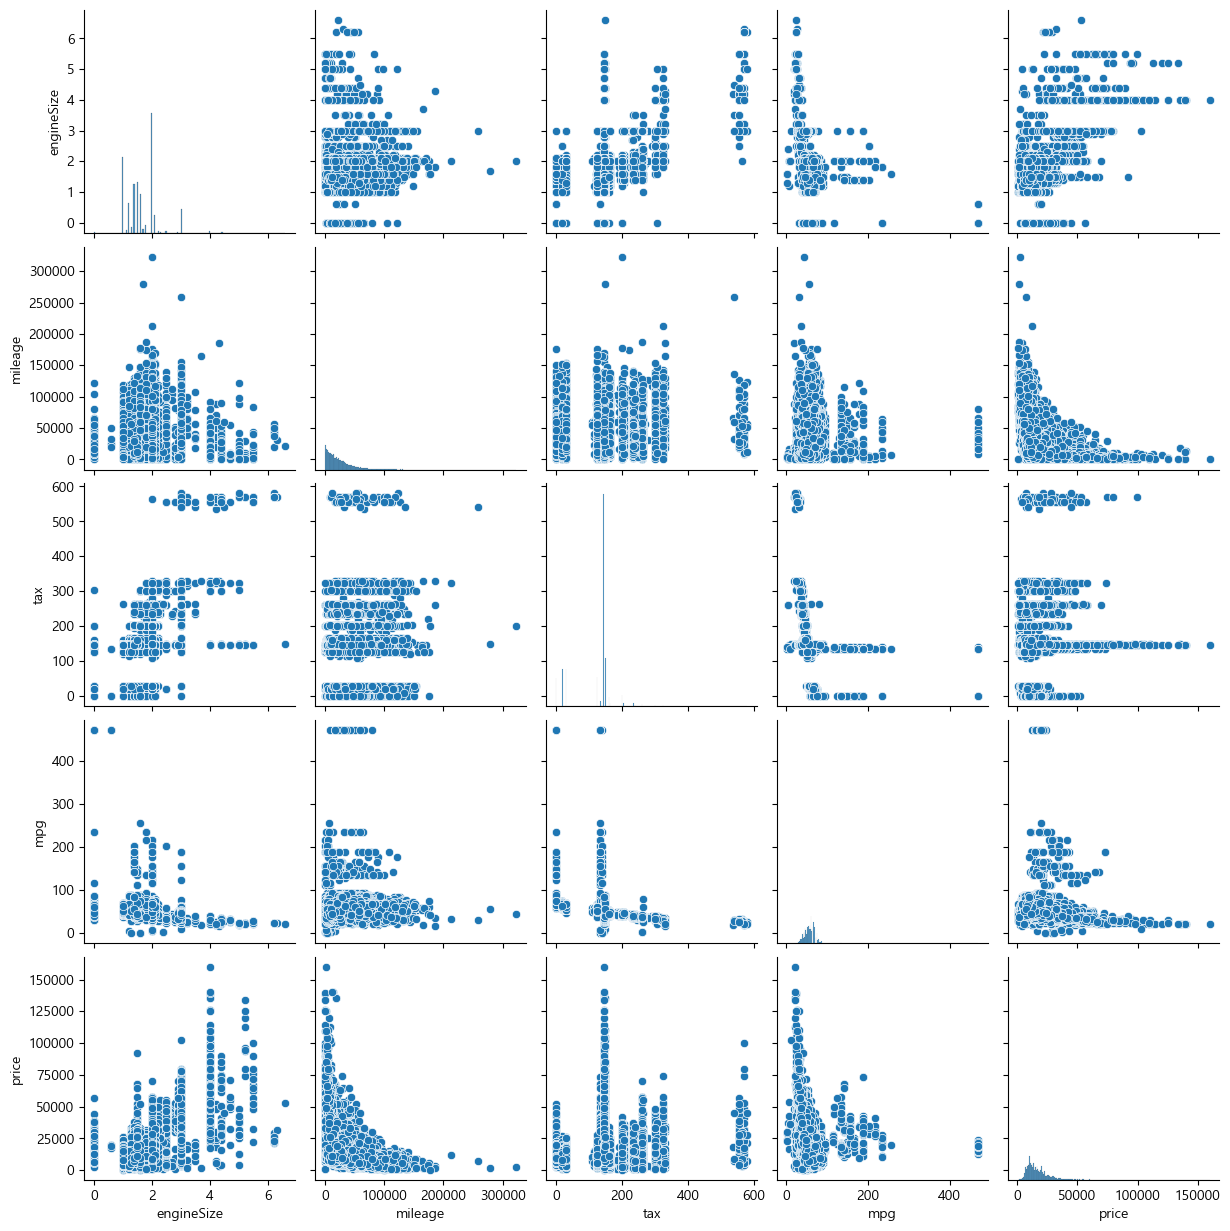

In [87]:
from sklearn.feature_selection import mutual_info_regression
import pandas as pd
import seaborn as sns

X = train[['mileage','tax','mpg','price']]
y = train['engineSize']

# A) Mutual Information
mi = mutual_info_regression(X.fillna(0), y.fillna(y.mean()))
mi_series = pd.Series(mi, index=X.columns).sort_values(ascending=False)
print("Mutual Information:\n", mi_series)

# B) 산점도 매트릭스
sns.pairplot(train[['engineSize','mileage','tax','mpg','price']].dropna())


In [88]:
n_samples, n_features = train.shape
print(f"샘플 수: {n_samples}, 피처 수: {n_features}")

샘플 수: 58627, 피처 수: 10


In [ ]:
train['fuelType'].value_counts()

In [415]:
df[df['engineSize'].isnull()]

,brand,model,year,transmission,mileage,fuelType,tax,mpg,engineSize,price,mileage_per_year


## 스케일러 적용
- 가지고 있는 데이터에 이상치가 존재하기 때문에 RobustScaler 적용
- 이상치의 영향을 최소화


In [416]:
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()
numeric_cols = ['tax', 'mpg', 'mileage_per_year', 'engineSize']
df_sclaed = df.copy()
df_sclaed[numeric_cols] = scaler.fit_transform(df[numeric_cols])

In [417]:
numeric_cols

['tax', 'mpg', 'mileage_per_year', 'engineSize']

In [418]:
df_sclaed

,brand,model,year,transmission,mileage,fuelType,tax,mpg,engineSize,price,mileage_per_year
0,3,83.0,2015.0,0.0,18078.0,0.0,-6.25,0.828025,0.000,8995.0,-0.195254
1,4,8.0,2018.0,0.0,4350.0,0.0,0.00,0.929936,0.625,19499.0,-0.662221
2,5,112.0,2019.0,1.0,9373.0,0.0,0.00,0.828025,0.000,14395.0,-0.291938
3,6,170.0,2011.0,1.0,74488.0,4.0,2.75,-0.815287,0.000,5899.0,1.187404
4,4,32.0,2019.0,0.0,608.0,4.0,0.00,-0.770701,0.500,26949.0,-0.866935
...,...,...,...,...,...,...,...,...,...,...,...
97707,3,164.0,2016.0,1.0,48868.0,0.0,-5.75,0.471338,0.125,NaN,1.230389
97708,6,33.0,2019.0,0.0,8300.0,2.0,-0.50,1.273885,0.250,NaN,-0.362328
97709,4,54.0,2019.0,0.0,16916.0,0.0,0.00,0.726115,0.500,NaN,0.202895
97710,1,5.0,2014.0,0.0,27782.0,0.0,0.75,-0.248408,1.750,NaN,0.087293


### PCA 적용

In [419]:
df_sclaed = df_sclaed.drop('price', axis=1)

In [420]:
# prompt: pca를 적용하는 코드를 작성해줘

import pandas as pd
from sklearn.decomposition import PCA

# PCA 객체 생성 (주성분 개수 지정)
pca = PCA(n_components=4)  # 예시: 주성분 5개 추출

# PCA 적용 (수치형 데이터에만 적용)
pca_result = pca.fit_transform(df_sclaed[numeric_cols])

# PCA 결과를 데이터프레임에 추가
pca_df = pd.DataFrame(data=pca_result, columns=[f'PC{i+1}' for i in range(pca.n_components_)])
df_sclaed = pd.concat([df_sclaed, pca_df], axis=1)

# 원래 수치형 데이터 삭제
df_sclaed.drop(numeric_cols, axis=1, inplace=True)

print(df_sclaed.head())


   brand  model    year  transmission  mileage  fuelType       PC1       PC2  \
0    3.0   83.0  2015.0           0.0  18078.0       0.0 -5.095537 -0.219109   
1    4.0    8.0  2018.0           0.0   4350.0       0.0  1.104996  0.782089   
2    5.0  112.0  2019.0           1.0   9373.0       0.0  1.057537  0.846271   
3    6.0  170.0  2011.0           1.0  74488.0       4.0  3.926854  0.114293   
4    4.0   32.0  2019.0           0.0    608.0       4.0  1.376623 -0.865046   

        PC3       PC4  
0 -0.409654  0.517041  
1 -0.505276  0.989717  
2 -0.513127  0.260549  
3  0.944846 -0.987238  
4 -0.503060  0.586160  


## 학습 데이터와 테스트 데이터로 다시 분리
- 가공이 끝난 데이터를 train과 test데이터로 다시 분리

In [148]:
train=df[~df['price'].isnull()]
test=df[df['price'].isnull()]

test=test.drop('price', axis=1)

### 학습 데이터를 검증 데이터로 분리하고 학습 수행

In [151]:
from sklearn.model_selection import train_test_split

# ftr_은 featrue의 약자
ftr_car=train.drop(['price'], axis=1)
target_car=train['price']

X_train, X_valid, y_train, y_valid = train_test_split(ftr_car, target_car, test_size=0.2, random_state=42)
X_train.shape, X_valid.shape, y_train.shape, y_valid.shape

((46900, 9), (11725, 9), (46900,), (11725,))

# 모델 구축

- 스케일러 적용이 필요한 모델과 스케일러 적용이 불필요한 모델로 나눠서 모델 학습 진행 필요

In [155]:
from sklearn.model_selection import KFold

kf = KFold(n_splits=5, shuffle=True, random_state=42)
# --- 모델 정의 (주어진 최적 하이퍼파라미터 사용) ---
# 최적의 하이퍼 파라미터 - 그리드서치를 통해 나온 하이퍼파라미터 사용
# Linear Regression  최적 파라미터: {}
# Ridge 최적 파라미터: {'alpha': 0.1}
# Lasso 최적 파라미터: {'alpha': 0.1}
# Random Forest 최적 파라미터: {'max_depth': None, 'n_estimators': 100}
# Gradient Boosting  {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100}
# --- 주어진 최적 하이퍼파라미터로 모델 정의 ---
models = {
    # "Linear Regression": LinearRegression(),  # 별도의 하이퍼파라미터 없음
    # "Ridge": Ridge(alpha=0.1),
    # "Lasso": Lasso(alpha=0.1, max_iter=5000),  # 시간이 너무 오래 걸림(밥먹으러 가기 전에 돌리세요~)
    "Random Forest": RandomForestRegressor(n_estimators=100, max_depth=None, random_state=84),
    # "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=84)
}

# --- 모델별 교차검증 및 Validation 성능 평가 ---
results = []
trained_models = {}  # 각 모델의 학습된 모델 저장

for name, model in models.items():
    print(f"\n🔍 모델: {name}")

    # 교차검증: Neg MSE를 RMSE로 변환 (여러 fold의 평균)
    neg_mse_scores = cross_val_score(model, X_train, y_train, cv=kf, scoring="neg_mean_squared_error", n_jobs=-1)
    cv_rmse = np.mean(np.sqrt(-neg_mse_scores))

    # 교차검증 R²
    cv_r2_scores = cross_val_score(model, X_train, y_train, cv=kf, scoring="r2", n_jobs=-1)
    cv_r2 = np.mean(cv_r2_scores)

    # 모델 학습 및 Validation 평가
    model.fit(X_train, y_train)
    trained_models[name] = model  # 학습된 모델 저장
    preds = model.predict(X_valid)
    val_rmse = np.sqrt(mean_squared_error(y_valid, preds))
    val_r2 = r2_score(y_valid, preds)

    print(f"  CV RMSE: {cv_rmse:.4f}")
    print(f"  CV R²: {cv_r2:.4f}")
    print(f"  Validation RMSE: {val_rmse:.4f}")
    print(f"  Validation R²: {val_r2:.4f}")

    results.append({
        "Model": name,
        "CV RMSE": cv_rmse,
        "CV R2": cv_r2,
        "Validation RMSE": val_rmse,
        "Validation R2": val_r2
    })

# 결과 DataFrame 출력
results_df = pd.DataFrame(results)
print("\n=== 모델 성능 평가 결과 ===")
print(results_df)

# --- 최적 모델 선택 ---
# 예를 들어, Validation R² 기준으로 가장 높은 모델을 선택합니다.
best_model_name = results_df.sort_values(by='Validation R2', ascending=False).iloc[0]['Model']
print(f"\n🏆 최적 모델: {best_model_name}")

# 저장해둔 학습된 모델에서 최적 모델 가져오기
best_model = trained_models[best_model_name]

# 예측
preds = best_model.predict(test)

print(preds[:10])


🔍 모델: Random Forest
  CV RMSE: 2153.6582
  CV R²: 0.9511
  Validation RMSE: 2116.1932
  Validation R²: 0.9586

=== 모델 성능 평가 결과 ===
           Model      CV RMSE     CV R2  Validation RMSE  Validation R2
0  Random Forest  2153.658173  0.951064      2116.193232       0.958561

🏆 최적 모델: Random Forest
[19836.58 15306.82 11832.75 16418.68 19411.42  5393.75 10885.75 10566.84
 22303.56 29420.4 ]


In [156]:
# 예측
preds = best_model.predict(test)

print(preds[:10])

[19836.58 15306.82 11832.75 16418.68 19411.42  5393.75 10885.75 10566.84
 22303.56 29420.4 ]


In [157]:
# 답안지 가져오기
submission = pd.read_csv('./dataset/sample_submission.csv')
submission['price'] = preds

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/Colab Notebooks/부산대학교/IBA/회귀/프로젝트/sample_submission.csv'

In [ ]:
# 답안 작성
submission.to_csv('./result/submit_knn_imputer.csv', index = False)

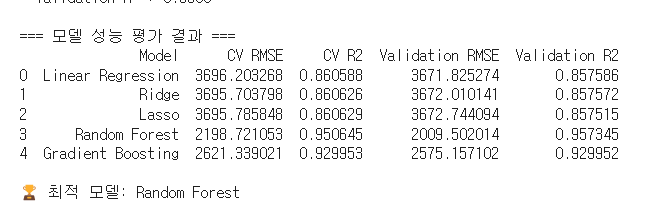

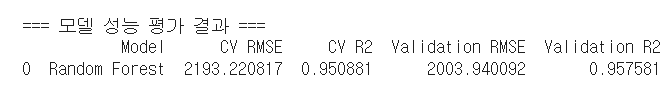

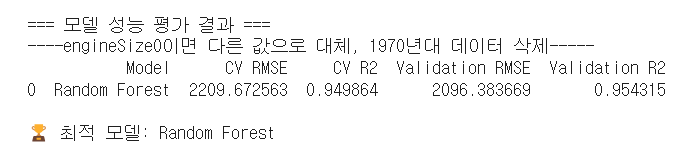

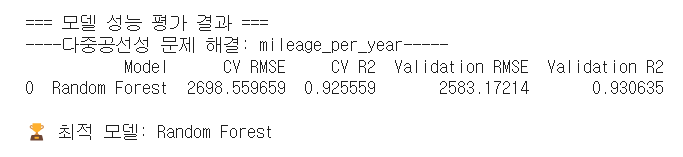

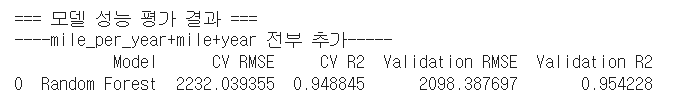

레이블 인코딩 적용 (sample_label)

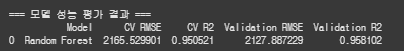

- knn보간법 적용-

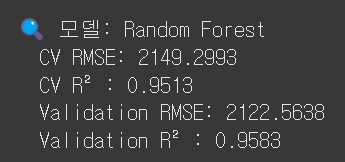

# 호영's Mission
1. 브랜드별 소비자의 구매행동 차이를 밝혀보세요
2. 중고로 차를 판매할 것이라는 가정하에 우리팀이라면 어떤 브랜드의 차를 구매할지 알려주세요
   

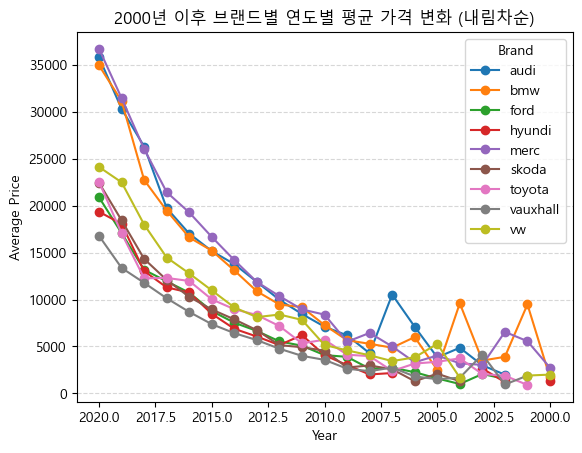

In [44]:
import matplotlib.pyplot as plt

# 1. 2000년 이후 데이터만 필터링
filtered = train[train['year'] >= 2000]

# 2. 브랜드-연도별 평균 가격 계산
grouped = (
    filtered
    .groupby(['brand', 'year'])['price']
    .mean()
    .reset_index()
)

# 3. 피벗: 연도별 행, 브랜드별 열
pivoted = grouped.pivot(index='year', columns='brand', values='price')

# 4. 선 그래프 그리기
plt.figure()
ax = plt.gca()  # 현재 Axes 가져오기
for brand in pivoted.columns:
        ax.plot(
        pivoted.index,
        pivoted[brand],
        label=brand,
        marker='o'           # 포인트가 보이도록 마커 추가
    )

# 5. x축 뒤집기 (2020 → 2000)
ax.invert_xaxis()

# 6. 나머지 설정
ax.set_xlabel('Year')
ax.set_ylabel('Average Price')
ax.set_title('2000년 이후 브랜드별 연도별 평균 가격 변화 (내림차순)')
ax.legend(title='Brand')
ax.grid(True, axis='y', linestyle='--', alpha=0.5)

plt.show()
